In [1]:
from CoupledQuantumSystems.systems import FluxoniumOscillatorSystem
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import qutip

In [2]:
from CoupledQuantumSystems.systems import *
from CoupledQuantumSystems.drive import *
from CoupledQuantumSystems.evo_parrallel import *

max_ql = 13
max_ol = 15
EJ = 4
EC = EJ/2.7
EL = EJ/45
Er = 10.38695526

g = 0.2
w_d = 10.389507326769158
amp = 0.005
tot_time =30

tlist = np.linspace(0, tot_time, tot_time)
system  =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
                computaional_states = '1,2',
                )


systems = [system,system,system]

initial_states  = [
    qutip.basis(max_ql * max_ol, system.product_to_dressed[(ql,0)]) for ql in [0,1,2]
    ]


list_of_systems = []
list_of_kwargs = []
for system, y0 in zip(systems, initial_states):
    list_of_systems.append(system)
    list_of_kwargs.append( {
        'y0':system.truncate_function(y0) ,
        'tlist':tlist,
        'drive_terms':[DriveTerm( 
                            driven_op= system.driven_operator,
                            pulse_shape_func=square_pulse_with_rise_fall,
                            pulse_id = None,
                            pulse_shape_args={
                                'w_d': w_d,
                                'amp': amp,
                                't_rise': 20,
                                't_square': tot_time
                            })],
        'e_ops':[system.a_trunc , system.a_trunc.dag()*system.a_trunc],
        # 'c_ops':[kappa *qutip.lindblad_dissipator(system.a_trunc) ]
        })
    

results = run_parallel_ODEsolve_and_post_process_jobs_with_different_systems(
    list_of_systems,
    list_of_kwargs,
    post_processing = ['pad_back']
)


import pickle
with open('sesolve_large_dim_a005.pkl', 'wb') as file:
    pickle.dump(results, file)

 Total run time:   4.43s ] Elapsed 4.43s / Remaining 00:00:00:00
 Total run time:   4.44s ] Elapsed 4.44s / Remaining 00:00:00:00
 Total run time:   4.48s ] Elapsed 4.48s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 30/30 [00:00<00:00, 2728.06it/s]


In [3]:
with open('sesolve_large_dim_a005.pkl', 'rb') as file:
    results = pickle.load(file)

In [4]:
states_in_product_basis = system.convert_dressed_to_product_vectorized(results[1].states,
                                                                        system.products_to_keep,
                                                                        )

In [6]:
states_in_product_basis[0]

Quantum object: dims = [[13, 15], [13, 15]], shape = (195, 195), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

(0.0, 470.0)

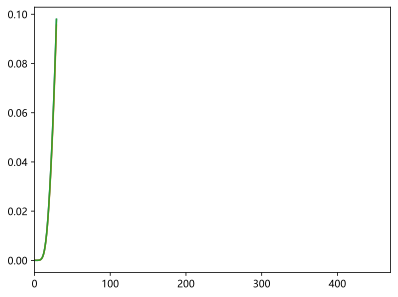

In [4]:
for i in [0,1,2]:
    plt.plot(results[i].expect[1])
plt.xlim(0,470)

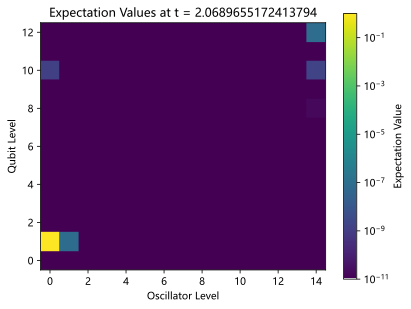

In [6]:
from CoupledQuantumSystems.visualization import *
plot_heatmap(results[1],2,system.product_to_dressed,max_ql,max_ol,LogNorm())

In [7]:
lists = []
for ql in [0 ,1, 2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 1
        for q in range(max_ql):
            if q == ql:
                for o in range(max_ol):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = system.truncate_function(qutip.basis(max_ql * max_ol,  dressed_state))
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum -= expectation_value

        pop_list.append(pop_sum)
    lists.append(pop_list)


t loop: 100%|██████████| 3/3 [00:00<00:00, 112.13it/s]


Text(0.5, 0, 't (ns)')

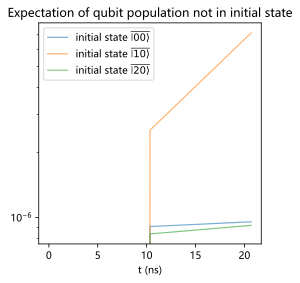

In [8]:
# from utils_models import *
plt.figure(figsize=(4,4))
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist[::10],pop_list,label = rf"initial state $\overline{{\left|{ql}0\right>}}$",linewidth =1.2,alpha = 0.6)
plt.yscale('log')
# plt.ylim(1e-6,1)
plt.legend()
# plt.title('expecation of qubit not being in initial state,\n sesolve with 15 level qbt, 40 level osc')
plt.title('Expectation of qubit population not in initial state')
plt.xlabel('t (ns)')

In [9]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(max_ql)]
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(max_ql):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = system.truncate_function(qutip.basis(max_ql*max_ol, dressed_state))
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)


t loop: 100%|██████████| 3/3 [00:00<00:00,  8.61it/s]


Text(0.5, 0, 't (ns)')

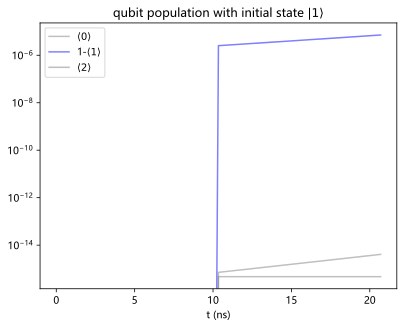

In [10]:
initial_ql = 1

qls = list(range(len(lists[0][0])))
for ql,pop_list in zip(qls,lists[initial_ql]): 
    if ql == initial_ql:
        plt.plot(tlist[::10],1-np.array(pop_list),label = rf"1-$\langle{ql}\rangle$",color='blue',alpha=0.5)
    elif ql != 10:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='grey',alpha=0.5)
    else:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='red',alpha=0.5)


# plt.axvline(x=656, color='k', linestyle='--')

plt.title(rf'qubit population with initial state $|{initial_ql}\rangle$')
plt.yscale('log')
plt.legend()
plt.legend()
plt.xlabel('t (ns)')